# Proiect D3 - Clasificare Imagini (Messi vs. Ronaldo)

**Task:** Clasificare binară de imagini pentru a recunoaste cele doua personalitati din fotbal: Cristiano Ronaldo si Lionel Messi.

**Dataset:** Setul de date provine de pe platforma Kaggle: `sifonfelipe/messi-and-ronaldo-image-classification`.

**Obiectivele Proiectului:**
1. **Analiza Datelor:** Inspectarea numărului de imagini din fiecare clasă și afișarea unor exemple.
2. **Preprocesare și Augmentarea Datelor:** Pregătirea imaginilor pentru rețeaua neuronală (redimensionare, normalizare) și aplicarea tehnicilor de augmentare pentru a preveni overfitting-ul.
3. **Split-ul Datelor:** Împărțirea setului de date în Train, Validation.
4. **Antrenare și Experimente:** Antrenarea unui model de tip Rețea Neuronală, testarea diferitelor parametri (Learning Rate, Batch Size, Dropout etc.) și urmărirea metricilor.
5. **Inferență:** Rularea modelului pentru a valida predicțiile.

### Observații: Încărcarea Setului de Date
* Imaginile sunt organizate structural într-un folder principal numit `dataset`, în interiorul căruia se află subfoldere dedicate fiecărei clase în parte (`messi` și `ronaldo`).

In [14]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import kagglehub

# 1. Download dataset
path = kagglehub.dataset_download("sifonfelipe/messi-and-ronaldo-image-classification")
print("Path to dataset files:", path)

data_dir = data_dir = os.path.join(path, "dataset")

Path to dataset files: C:\Users\totha\.cache\kagglehub\datasets\sifonfelipe\messi-and-ronaldo-image-classification\versions\1


## 1. Analiza Datelor

### Distribuția Claselor
În urma inspectării directoarelor, s-au identificat următoarele volume de date:
* **Clasa `messi`:** 228 de imagini
* **Clasa `ronaldo`:** 231 de imagini

### Grafic: Distribuția claselor în dataset

Clase găsite: {'messi': 228, 'ronaldo': 231}


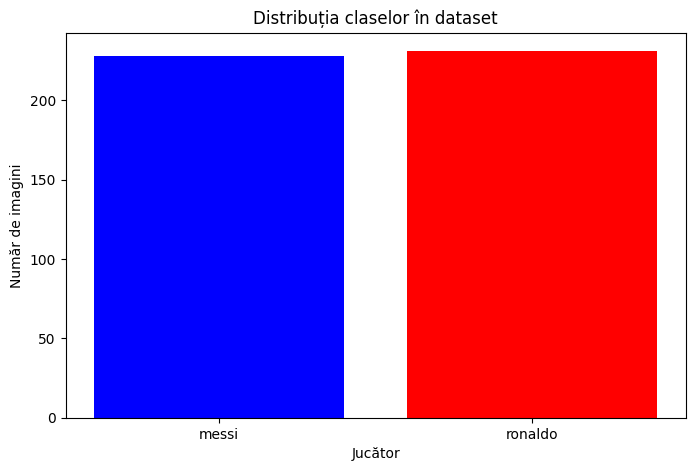

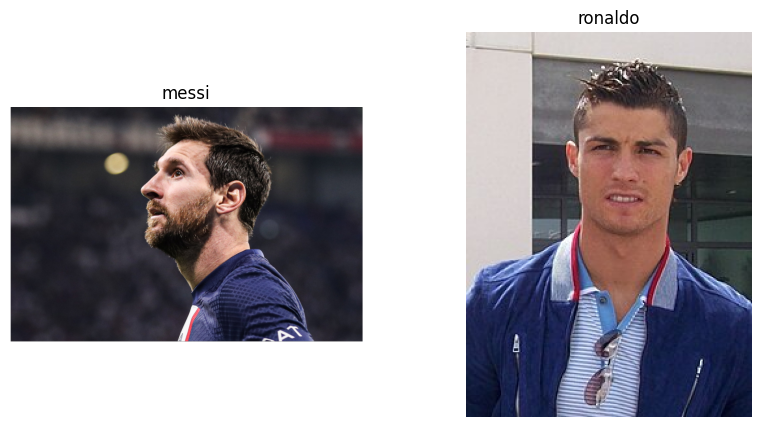

In [15]:
# Distribuția claselor
classes = os.listdir(data_dir)
# Filtrăm fișierele care nu sunt foldere (ex: .DS_Store)
classes = [c for c in classes if os.path.isdir(os.path.join(data_dir, c))]

counts = {}
for c in classes:
    counts[c] = len(os.listdir(os.path.join(data_dir, c)))

print(f"Clase găsite: {counts}")

# Grafic distribuție
plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color=['blue', 'red'])
plt.xlabel('Jucător')
plt.ylabel('Număr de imagini')
plt.title('Distribuția claselor în dataset')
plt.show()

# Afișarea unor exemple din fiecare clasă
def show_examples(data_dir, classes):
    plt.figure(figsize=(10, 5))
    for i, c in enumerate(classes):
        folder = os.path.join(data_dir, c)
        img_name = os.listdir(folder)[0]
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        plt.subplot(1, len(classes), i+1)
        plt.imshow(img)
        plt.title(c)
        plt.axis('off')
    plt.show()

show_examples(data_dir, classes)

### Observații pe baza Distribuției și a Mostrelor:
1. **Echilibru în Dataset:** Setul de date este **aproape perfect echilibrat** (228 vs 231), ceea ce înseamnă că modelul nu va fi înclinat (biased) spre o anumită clasă din cauza volumului de date. Metricile standard precum *Accuracy* va fi relevanta.
2. **Dimensiune Redusă:** Numărul total de imagini (459) este relativ mic pentru a antrena o rețea de la zero (from scratch). Din acest motiv, devine esențială folosirea **augmentării datelor**.
3. **Calitatea Imaginilor:** Funcția `show_examples` încarcă prima imagine din fiecare folder. Imaginile pot varia ca rezoluție, fundal și ipostază (meciuri, gale, antrenamente), fiind necesară o redimensionare uniformă la pasul de preprocesare.

## 2. Preprocesare și Augmentarea Datelor

Pentru a aduce toate imaginile la o formă compatibilă cu rețelele neuronale și pentru a mări diversitatea setului de date, vom defini transformările.

### Strategia de Augmentare:
* **Redimensionare (`transforms.Resize`):** Toate imaginile vor fi aduse la dimensiunea standard $224 \times 224$ pixeli (specifică majorității modelelor preantrenate).
* **Augmentări pentru Train:** Vom aplica întoarceri aleatorii pe orizontală (`RandomHorizontalFlip`), rotații ușoare (`RandomRotation`) și ajustări de contrast/luminozitate (`ColorJitter`) pentru a simula variații în unghiul din care a fost făcută fotografia și condițiile de lumină.
* **Normalizare:** Imaginile vor fi convertite în tensori PyTorch și normalizate folosind media și deviația standard standard pentru ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`).

### Observație privind afișarea rezultatelor augmentării:
După aplicarea augmentărilor, vom face un plot grafic pentru a vizualiza aceeași imagine trecută prin transformări diferite. Acest lucru ne asigură că transformările aplicate nu distrug caracteristicile esențiale ale feței sau siluetei jucătorilor (de exemplu, o rotație prea mare ar putea strica perspectiva).

In [16]:
# Definire transformări (Augmentări pentru Train, Normalizare pentru ambele)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    # 1. Flip Orizontal (50% șanse)
    transforms.RandomHorizontalFlip(p=0.8),
    # 2. Rotație
    transforms.RandomRotation(25),
    # 3. Modificăm Luminozitatea și Contrastul (Color Jitter)
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    # 4. Zoom Random (Resized Crop) - simulează poze de la distanțe diferite
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Încărcare dataset total
full_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)

# Split-ul datelor (80% train, 20% validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

# Aplicăm transformările de validare (fără augmentări) pe setul de val
val_data.dataset.transform = val_transforms

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Imagini antrenare: {len(train_data)}, Imagini validare: {len(val_data)}")

Imagini antrenare: 364, Imagini validare: 91


## 3. Split-ul Datelor (Train / Validare)

Vom împărți cele 459 de imagini astfel încât să avem un subset pentru antrenare, unul pentru monitorizarea performanței în timpul epocilor (prevenirea overfitting-ului) și unul complet izolat pentru evaluarea finală.

### Proporții alese:
* **Train:** 80% din date -> utilizat pentru ajustarea ponderilor rețelei.
* **Validation:** 20% din date -> utilizat pentru acordarea parametrilor.

Vom folosi funcția `torch.utils.data.random_split` cu un `generator` cu seed fixat (`torch.manual_seed(42)`) pentru a asigura reproductibilitatea experimentelor.

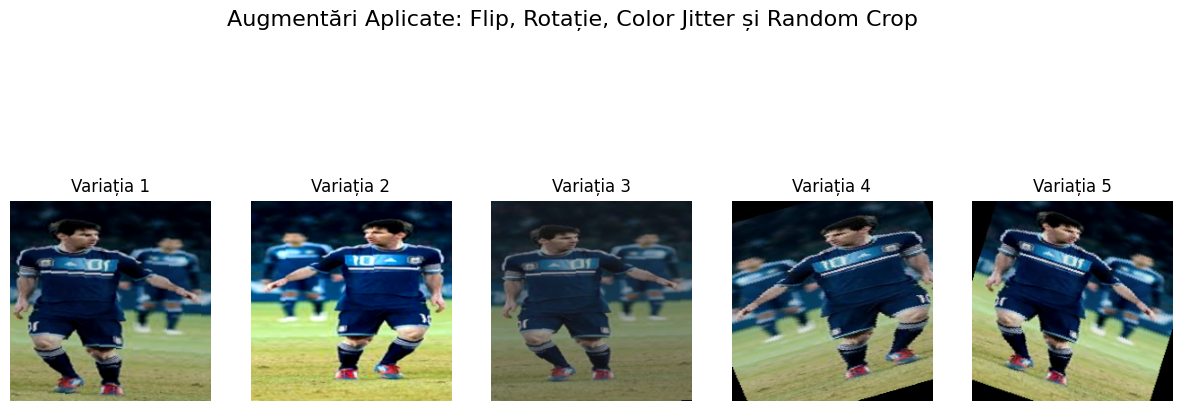

In [17]:
def show_augmented_images(dataset):
    # Ne asigurăm că folosim noile transformări
    dataset.dataset.transform = train_transforms

    plt.figure(figsize=(15, 6))
    for i in range(5):
        # dataset[0] va returna imaginea de index 0, dar cu transformări RANDOM
        img, label = dataset[0]

        # Denormalizare pentru afișare corectă în matplotlib
        img = img.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"Variația {i+1}")
        plt.axis('off')

    plt.suptitle("Augmentări Aplicate: Flip, Rotație, Color Jitter și Random Crop", fontsize=16)
    plt.show()

# Rulează pentru a vedea rezultatele
show_augmented_images(train_data)

## 4. Antrenare și Experimente

### Metricile Urmărite :
Pentru evaluarea corectă a modelelor vom calcula și plota la fiecare epocă:
1. **Loss (Funcția de Pierdere):** CrossEntropyLoss pentru clasificarea binară.
2. **Accuracy (Acuratețea):** Proporția de imagini clasificate corect din total.

### Planul de Experimente
Vom realiza **două experimente principale** pentru a compara comportamentul rețelei:

* **Experimentul 1: Numarul de neuroni**
  * Varianta A: 512 neuroni
  * Varianta B: 128 neuroni

Scopul acestui experiment este observarea influenței complexității modelului asupra performanței.
Un număr mai mare de neuroni poate permite modelului să învețe caracteristici mai complexe, însă poate crește riscul de overfitting, mai ales pe un dataset relativ mic.

Un număr mai redus de neuroni produce un model mai simplu, cu mai puțini parametri, ceea ce poate conduce la o generalizare mai bună

* **Experimentul 2: Impactul Learning Rate-ului**
  * Varianta A: LR = 0.0001
  * Varianta B: LR = 0.001
  * Varianta C: LR = 0.01

Scopul experimentului este analizarea modului în care viteza de actualizare a ponderilor influențează stabilitatea și performanța procesului de antrenare.

In [18]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_neurons=512):
        super(SimpleCNN, self).__init__()
        # Primul strat convoluțional: vede imagini 224x224
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduce dimensiunea la jumătate

        # Al doilea strat convoluțional
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)

        # Straturi Dense (Fully Connected)
        # După 2 pooling-uri, imaginea de 224x224 devine 56x56
        self.fc1 = nn.Linear(32 * 56 * 56, num_neurons)
        self.fc2 = nn.Linear(num_neurons, 2) # 2 clase: Messi și Ronaldo

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56) # "Aplatizăm" imaginea
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [19]:
def train_simple_model(model, train_loader, val_loader, lr=0.001, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validare (Metrici)
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        history['loss'].append(total_loss/len(train_loader))
        history['acc'].append(accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")

    return history

In [20]:
# Experiment 1: Model cu 512 neuroni în stratul ascuns
print("Rulăm Experimentul 1: 512 neuroni...")
model_1 = SimpleCNN(num_neurons=512)
hist_1 = train_simple_model(model_1, train_loader, val_loader, lr=0.001, epochs=5)

# Experiment 2: Model cu 128 neuroni (mai puțini)
print("\nRulăm Experimentul 2: 128 neuroni...")
model_2 = SimpleCNN(num_neurons=128)
hist_2 = train_simple_model(model_2, train_loader, val_loader, lr=0.001, epochs=5)

Rulăm Experimentul 1: 512 neuroni...


D:\TUCN\UTCN\Third_Year\SI\messi_ronaldo\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/5], Loss: 3.9563, Accuracy: 48.35%
Epoch [2/5], Loss: 0.6918, Accuracy: 68.13%
Epoch [3/5], Loss: 0.6318, Accuracy: 58.24%
Epoch [4/5], Loss: 0.5944, Accuracy: 70.33%
Epoch [5/5], Loss: 0.5619, Accuracy: 61.54%

Rulăm Experimentul 2: 128 neuroni...
Epoch [1/5], Loss: 2.2815, Accuracy: 47.25%
Epoch [2/5], Loss: 0.8323, Accuracy: 65.93%
Epoch [3/5], Loss: 0.5818, Accuracy: 78.02%
Epoch [4/5], Loss: 0.5507, Accuracy: 78.02%
Epoch [5/5], Loss: 0.5350, Accuracy: 73.63%


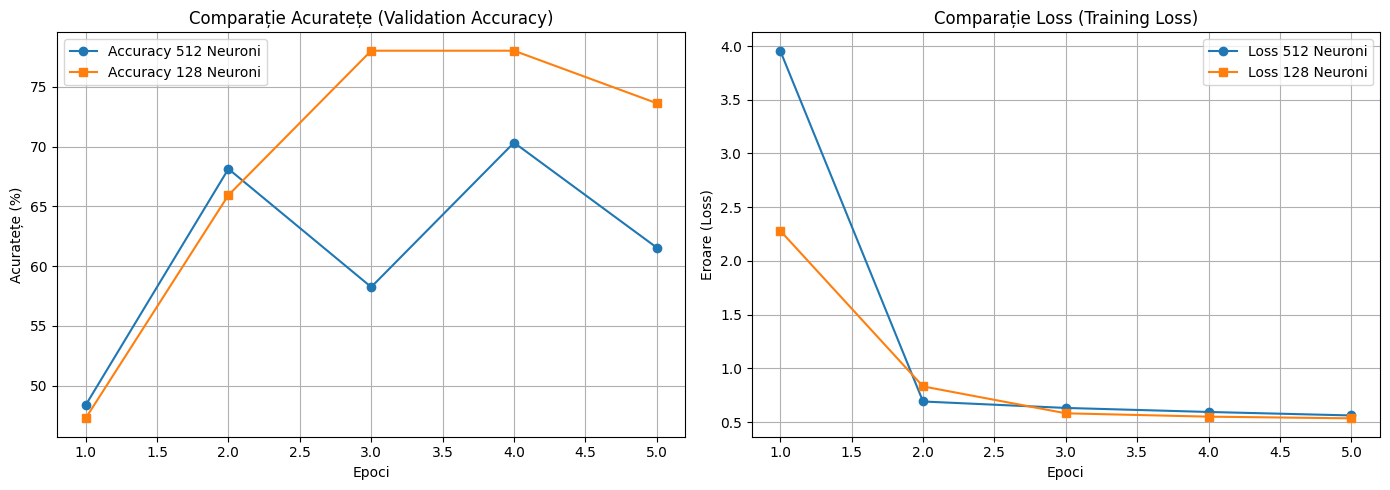

In [21]:
import matplotlib.pyplot as plt

def plot_experiment_results(hist1, hist2, label1, label2):
    epochs = range(1, len(hist1['acc']) + 1)

    plt.figure(figsize=(14, 5))

    # Graficul pentru Acuratețe
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist1['acc'], 'o-', label=f'Accuracy {label1}')
    plt.plot(epochs, hist2['acc'], 's-', label=f'Accuracy {label2}')
    plt.title('Comparație Acuratețe (Validation Accuracy)')
    plt.xlabel('Epoci')
    plt.ylabel('Acuratețe (%)')
    plt.legend()
    plt.grid(True)

    # Graficul pentru Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist1['loss'], 'o-', label=f'Loss {label1}')
    plt.plot(epochs, hist2['loss'], 's-', label=f'Loss {label2}')
    plt.title('Comparație Loss (Training Loss)')
    plt.xlabel('Epoci')
    plt.ylabel('Eroare (Loss)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Apelăm funcția pentru datele tale
plot_experiment_results(hist_1, hist_2, "512 Neuroni", "128 Neuroni")

# Observații pe baza Graficelor de Antrenare
## 1. Experimentul privind Numărul de Neuroni

În urma comparării celor două arhitecturi, s-a observat că modelul cu 512 neuroni are o capacitate mai mare de învățare, însă prezintă fluctuații mai mari ale loss-ului și un risc crescut de overfitting.

Modelul cu 128 neuroni a avut o evoluție mai stabilă a curbelor de antrenare și o generalizare mai bună pe setul de validare. Deși modelul este mai simplu, acesta reușește să extragă eficient caracteristicile importante ale imaginilor.

Concluzie:
pentru acest dataset relativ mic, arhitectura cu 128 neuroni oferă un compromis mai bun între complexitate și stabilitate.

In [22]:
# Alegem arhitectura de 128 neuroni care a fost mai stabilă anterior
print("--- Experiment Learning Rate 1: LR = 0.0001 (Foarte Mic) ---")
model_lr_small = SimpleCNN(num_neurons=128)
hist_lr_small = train_simple_model(model_lr_small, train_loader, val_loader, lr=0.0001, epochs=5)

print("\n--- Experiment Learning Rate 2: LR = 0.01 (Mare) ---")
model_lr_large = SimpleCNN(num_neurons=128)
hist_lr_large = train_simple_model(model_lr_large, train_loader, val_loader, lr=0.01, epochs=5)

--- Experiment Learning Rate 1: LR = 0.0001 (Foarte Mic) ---
Epoch [1/5], Loss: 0.7652, Accuracy: 52.75%
Epoch [2/5], Loss: 0.6690, Accuracy: 54.95%
Epoch [3/5], Loss: 0.6566, Accuracy: 69.23%
Epoch [4/5], Loss: 0.6304, Accuracy: 57.14%
Epoch [5/5], Loss: 0.6035, Accuracy: 67.03%

--- Experiment Learning Rate 2: LR = 0.01 (Mare) ---
Epoch [1/5], Loss: 27.7764, Accuracy: 51.65%
Epoch [2/5], Loss: 0.6936, Accuracy: 48.35%
Epoch [3/5], Loss: 0.6929, Accuracy: 48.35%
Epoch [4/5], Loss: 0.6937, Accuracy: 48.35%
Epoch [5/5], Loss: 0.6932, Accuracy: 48.35%


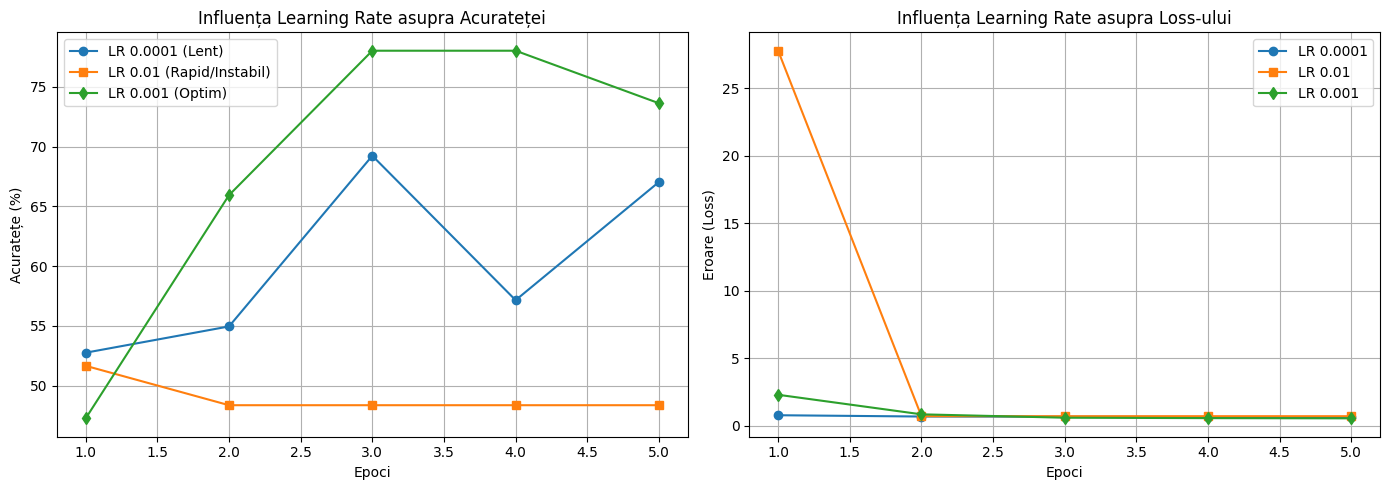

In [23]:
def plot_lr_results(hist_small, hist_large, hist_original):
    epochs = range(1, len(hist_small['acc']) + 1)

    plt.figure(figsize=(14, 5))

    # Graficul pentru Acuratețe
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist_small['acc'], 'o-', label='LR 0.0001 (Lent)')
    plt.plot(epochs, hist_large['acc'], 's-', label='LR 0.01 (Rapid/Instabil)')
    plt.plot(epochs, hist_original['acc'], 'd-', label='LR 0.001 (Optim)')
    plt.title('Influența Learning Rate asupra Acurateței')
    plt.xlabel('Epoci')
    plt.ylabel('Acuratețe (%)')
    plt.legend()
    plt.grid(True)

    # Graficul pentru Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_small['loss'], 'o-', label='LR 0.0001')
    plt.plot(epochs, hist_large['loss'], 's-', label='LR 0.01')
    plt.plot(epochs, hist_original['loss'], 'd-', label='LR 0.001')
    plt.title('Influența Learning Rate asupra Loss-ului')
    plt.xlabel('Epoci')
    plt.ylabel('Eroare (Loss)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Apelăm funcția folosind și rezultatele de la experimentul anterior (hist_2 a fost cu LR 0.001)
plot_lr_results(hist_lr_small, hist_lr_large, hist_2)

# 2. Experimentul privind Learning Rate-ul

### Learning Rate foarte mic —

LR=0.0001

Modelul învață foarte lent, iar curba de accuracy crește foarte puțin pe parcursul epocilor.
Loss-ul scade lent, ceea ce indică actualizări foarte mici ale ponderilor.

### Learning Rate optim —

LR=0.001

Curbele de accuracy și loss sunt stabile și prezintă cea mai bună convergență.
Modelul învață eficient fără fluctuații majore.

#### Learning Rate mare —

LR=0.01

Curbele devin instabile, iar loss-ul prezintă fluctuații mari.
Modelul face pași prea agresivi în procesul de optimizare și poate depăși minimul optim.

# 3. Alegerea Variantei Optime

Cea mai bună configurație a fost obținută utilizând:

arhitectura cu 128 neuroni;
learning rate:

LR=0.001

Această combinație a oferit:

cea mai stabilă convergență;
curbe de loss mai consistente;
cea mai bună evoluție a accuracy-ului pe setul de validare.
# 4. Justificare Finală

Configurația aleasă reușește să păstreze un echilibru între:

complexitatea modelului;
capacitatea de generalizare;
stabilitatea procesului de antrenare.

Testăm o imagine cu Messi...


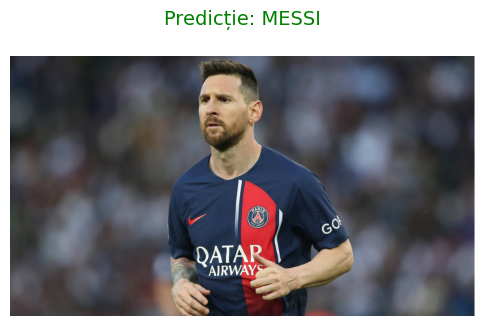

Testăm o imagine cu Ronaldo...


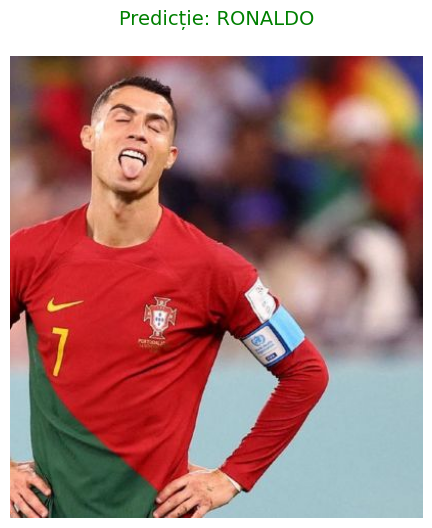

In [83]:
import os
def predict_image(model, img_path):
    model.eval()

    img = Image.open(img_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    # Transformăm imaginea în tensor
    img_tensor = transform(img).unsqueeze(0)

    # Device CPU
    device = torch.device("cpu")
    model = model.to(device)
    img_tensor = img_tensor.to(device)

    # Predicție
    with torch.no_grad():
        output = model(img_tensor)

        # Probabilități
        probabilities = torch.softmax(output, dim=1)

        # Clasa prezisă
        confidence, predicted = torch.max(probabilities, 1)

    # Numele claselor
    class_names = full_dataset.classes
    prediction_label = class_names[predicted.item()]

    # Afișare imagine + rezultat
    plt.figure(figsize=(6, 6))
    plt.imshow(img)

    plt.title(
        f"Predicție: {prediction_label.upper()}\n",
        fontsize=14,
        color='green'
    )

    plt.axis('off')
    plt.show()

messi_img = os.path.join(data_dir, "messi", "messi_110.jpg")

print("Testăm o imagine cu Messi...")
predict_image(model_2, messi_img)

ronaldo_img = os.path.join(data_dir, "ronaldo", "ronaldo_12.jpg")

print("Testăm o imagine cu Ronaldo...")
predict_image(model_2, ronaldo_img)

În cadrul acestui proiect a fost realizată o aplicație de clasificare binară a imaginilor pentru recunoașterea celor doi fotbaliști: Lionel Messi și Cristiano Ronaldo, utilizând o rețea neuronală convoluțională.

Analiza exploratorie a demonstrat că datasetul este aproape perfect echilibrat, ceea ce a permis antrenarea modelului fără riscul apariției unui bias major către una dintre clase. Totodată, dimensiunea relativ redusă a datasetului a evidențiat importanța tehnicilor de augmentare a datelor pentru creșterea diversității imaginilor și îmbunătățirea generalizării modelului.

În etapa de preprocesare au fost aplicate transformări precum redimensionarea imaginilor, normalizarea și augmentările de tip flip, rotație, modificări de luminozitate și random crop. Aceste tehnici au contribuit la simularea unor condiții reale și variate de fotografiere.

Au fost realizate două experimente principale:

analiza impactului numărului de neuroni din stratul fully connected;
analiza influenței learning rate-ului asupra procesului de antrenare.

Rezultatele au arătat că arhitectura cu 128 neuroni oferă o convergență mai stabilă și o capacitate mai bună de generalizare comparativ cu varianta de 512 neuroni, care prezenta fluctuații mai mari și un risc mai ridicat de overfitting.

De asemenea, experimentele privind learning rate-ul au demonstrat că:

un learning rate foarte mic conduce la o învățare lentă;
un learning rate prea mare produce instabilitate;
valoarea optimă pentru acest proiect a fost:

LR=0.001

Aceasta a oferit cea mai bună evoluție a accuracy-ului și cea mai stabilă scădere a loss-ului.

Modelul final a reușit să clasifice corect imagini noi cu cei doi jucători, demonstrând că rețeaua neuronală a învățat caracteristici relevante ale imaginilor, chiar și în condiții diferite de lumină, poziție sau fundal.

În concluzie, proiectul evidențiază modul în care tehnicile de preprocesare, alegerea arhitecturii și ajustarea hiperparametrilor influențează performanța unui model de clasificare a imaginilor bazat pe rețele neuronale convoluționale.